In [1]:
import glob
import numpy as np
import os
import matplotlib.pyplot as plt
from utils import *

In [2]:
def get_kBH_end_zs(sim_name, zs, all_feedback=True):
    kbh_data = {}
    for z in zs:
        if z == 0.0:
            filename = f'kbhinfo_{sim_name}.npz'
        else:
            filename = f'kbhinfo_{sim_name}_z{z:.1f}.npz'
        # check if file exists
        if not os.path.isfile(filename):
            print(f'File {filename} does not exist. Skipping z={z}.')
            continue
        kbh_data[z] = get_kBH_end(filename, all_feedback=all_feedback)
    return kbh_data

In [3]:
# load data
zs = np.array([0.0, 0.2, 0.5, 1.0, 1.5, 2.0])
line_widths = [3., 2.5, 2.0, 1.5, 1.0, 0.5]

sim_names = ['kn1-Repos1', 'kn1-DF', 'kn1S-Repos1', 'kn1S-DF']


kbh_Repos1 = get_kBH_end_zs(sim_names[0], zs)
kbh_DF = get_kBH_end_zs(sim_names[1], zs)
kbh_SRepos1 = get_kBH_end_zs(sim_names[2], zs)
kbh_SDF = get_kBH_end_zs(sim_names[3], zs)

# primary BHs only (feedback energy from secondary BHs is excluded)
kbh_SRepos1_prim = get_kBH_end_zs(sim_names[2], zs, all_feedback=False)
kbh_SDF_prim = get_kBH_end_zs(sim_names[3], zs, all_feedback=False)

Updating FirstReleaseTime of BHID 293032791 from 0.24117171640611984 to 0.2409724162921851 (from swallowed BHID 292219365)
Updating FirstReleaseTime of BHID 295070536 from 0.2619989123646749 to 0.2409724162921851 (from swallowed BHID 293032791)
Updating FirstReleaseTime of BHID 295899988 from 0.29121276986968453 to 0.2409724162921851 (from swallowed BHID 295070536)
Updating FirstReleaseTime of BHID 524201326 from 0.31990002990553174 to 0.2562380387965549 (from swallowed BHID 524195549)
Updating FirstReleaseTime of BHID 387659171 from 0.33098322890009513 to 0.32157787143554983 (from swallowed BHID 387255346)
Updating FirstReleaseTime of BHID 296720444 from 0.344440492749062 to 0.2409724162921851 (from swallowed BHID 295899988)
Updating FirstReleaseTime of BHID 298360777 from 0.3517932606046014 to 0.2409724162921851 (from swallowed BHID 296720444)
Updating FirstReleaseTime of BHID 433003952 from 0.3555821972248517 to 0.3486578631967217 (from swallowed BHID 428888739)
Updating FirstReleas

Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 1.418e+03 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 9.630e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 5.011e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 1.692e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 5.658e+01 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 2.154e+01 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 1.289e+03 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 8.550e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 4.274e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 1.337e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 4.318e+01 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+

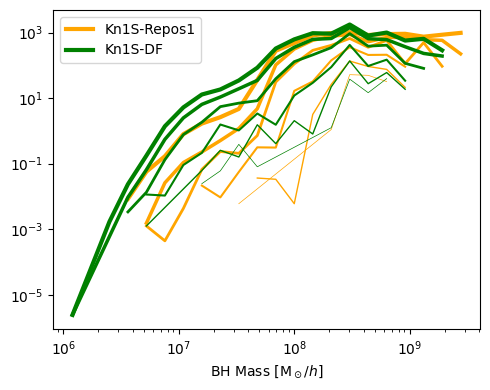

In [4]:
# plot energy distribution

fig, ax = plt.subplots(figsize=(5, 4))

m_lower = 1e6
m_upper = 1e10

# for i, z in enumerate(zs):
#     if z not in kbh_DF:
#         continue
#     plot_energy_density_distribution(
#         ax,
#         kbh_DF[z],
#         nbins=25,
#         color='blue',
#         xlower=m_lower,
#         xupper=m_upper,
#         label=f'Kn1-DF' if i == 0 else None,
#         linewidth=line_widths[i]
#         )


# for i, z in enumerate(zs):
#     if z not in kbh_Repos1:
#         continue
#     plot_energy_density_distribution(
#         ax,
#         kbh_Repos1[z],
#         nbins=25,
#         color='red',
#         xlower=m_lower,
#         xupper=m_upper,
#         label=f'Kn1-Repos1' if i == 0 else None,
#         linewidth=line_widths[i]
#         )

for i, z in enumerate(zs):
    if z not in kbh_SRepos1:
        continue
    plot_energy_density_distribution(
        ax,
        kbh_SRepos1[z],
        nbins=25,
        color='orange',
        xlower=m_lower,
        xupper=m_upper,
        label=f'Kn1S-Repos1' if i == 0 else None,
        linewidth=line_widths[i]
        )


for i, z in enumerate(zs):
    if z not in kbh_SDF:
        continue
    plot_energy_density_distribution(
        ax,
        kbh_SDF[z],
        nbins=25,
        color='green',
        xlower=m_lower,
        xupper=m_upper,
        label=f'Kn1S-DF' if i == 0 else None,
        linewidth=line_widths[i]
        )


# scale
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'BH Mass [M$_\odot/h$]')
# ax.set_ylabel(r'Energy Density [$c^2$M$_\odot/h$/Mpc$^3$]')
ax.legend()
plt.tight_layout()
plt.show()

Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 1.233e+03 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 1.071e+03 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 1.418e+03 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 1.289e+03 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 7.826e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 6.500e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 9.630e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 8.550e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 3.819e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 2.570e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 5.011e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+

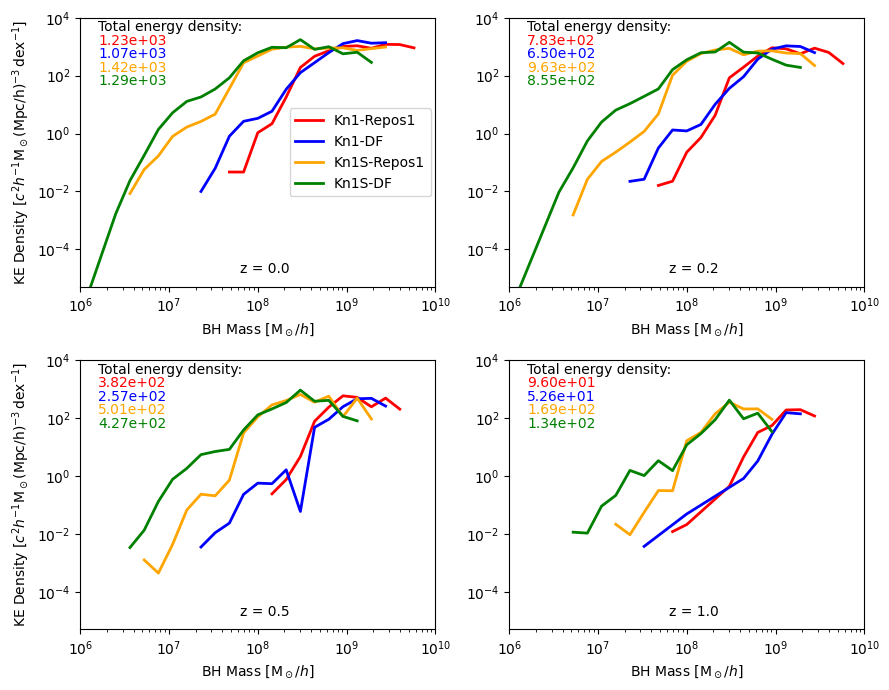

In [5]:
# 2x2 figure for redshifts

m_lower = 1e6
m_upper = 1e10
colors = ['red', 'blue', 'orange', 'green']

fig, axs = plt.subplots(2, 2, figsize=(9, 7))
axs = axs.flatten()

for i, z in enumerate(zs):
    if i >= 4:
        break
    ax = axs[i]
    if z in kbh_Repos1:
        u_tot_R1 = plot_energy_density_distribution(
            ax,
            kbh_Repos1[z],
            nbins=25,
            color=colors[0],
            xlower=m_lower,
            xupper=m_upper,
            label=f'Kn1-Repos1',
            linewidth=2.0
            )
    if z in kbh_DF:
        u_tot_DF = plot_energy_density_distribution(
            ax,
            kbh_DF[z],
            nbins=25,
            color=colors[1],
            xlower=m_lower,
            xupper=m_upper,
            label=f'Kn1-DF',
            linewidth=2.0
            )
    if z in kbh_SRepos1:
        u_tot_SR1 = plot_energy_density_distribution(
            ax,
            kbh_SRepos1[z],
            nbins=25,
            color=colors[2],
            xlower=m_lower,
            xupper=m_upper,
            label=f'Kn1S-Repos1',
            linewidth=2.0
            )
    if z in kbh_SDF:
        u_tot_SDF = plot_energy_density_distribution(
            ax,
            kbh_SDF[z],
            nbins=25,
            color=colors[3],
            xlower=m_lower,
            xupper=m_upper,
            label=f'Kn1S-DF',
            linewidth=2.0
            )
    # annotate total energy density for each model with different colors
    ax.text(0.05, .95, 'Total energy density:', transform=ax.transAxes)  # placeholder for alignment
    if z in kbh_Repos1:
        ax.text(0.05, 0.9, f'{u_tot_R1:.2e}', transform=ax.transAxes, color=colors[0])
    if z in kbh_DF:
        ax.text(0.05, 0.85, f'{u_tot_DF:.2e}', transform=ax.transAxes, color=colors[1])
    if z in kbh_SRepos1:
        ax.text(0.05, 0.8, f'{u_tot_SR1:.2e}', transform=ax.transAxes, color=colors[2])
    if z in kbh_SDF:
        ax.text(0.05, 0.75, f'{u_tot_SDF:.2e}', transform=ax.transAxes, color=colors[3])

    # ax.set_title(f'z = {z:.1f}')
    # annotate z using text instead of title
    ax.text(0.45, 0.05, f'z = {z:.1f}', transform=ax.transAxes)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'BH Mass [M$_\odot/h$]')
    if i % 2 == 0:
        ax.set_ylabel(r'KE Density [$c^2h^{-1}$M$_\odot$(Mpc/h)$^{-3}\,\mathrm{dex}^{-1}$]')
    # ax.legend()
    # x limit
    ax.set_xlim(m_lower, m_upper)
    ax.set_ylim(.5e-5, 1e4)
# legend only for the first subplot
axs[0].legend(loc='center left', bbox_to_anchor=(.57, 0.5))
plt.tight_layout()
plt.show()

Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 1.233e+03 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 1.071e+03 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 1.418e+03 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 1.289e+03 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 3.819e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 2.570e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 5.011e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 4.274e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 9.602e+01 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 5.258e+01 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 1.692e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+

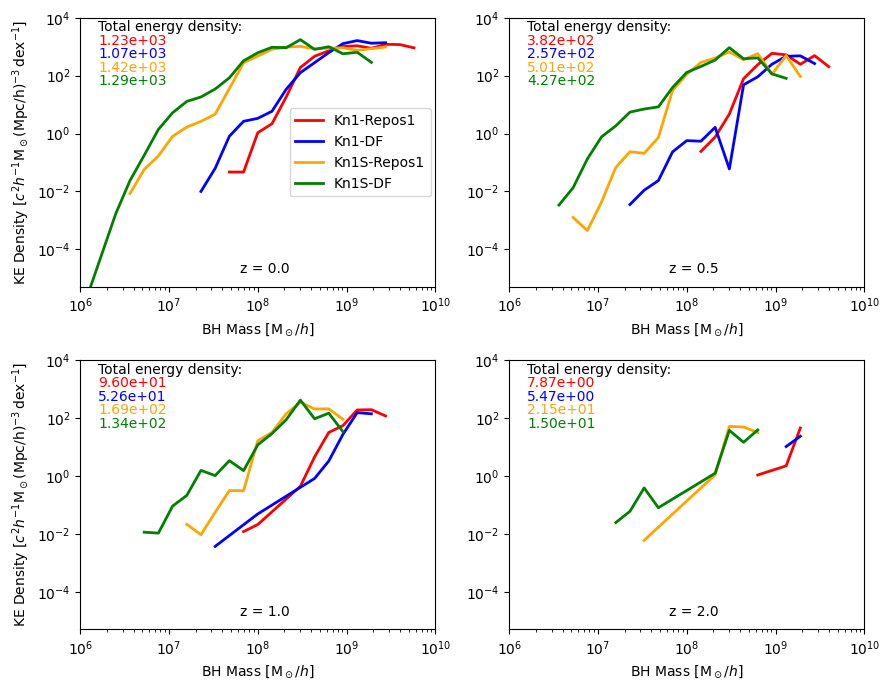

In [6]:
# 2x2 figure for redshifts

zs = np.array([0.0, 0.5, 1.0, 2.0])

m_lower = 1e6
m_upper = 1e10
colors = ['red', 'blue', 'orange', 'green']

fig, axs = plt.subplots(2, 2, figsize=(9, 7))
axs = axs.flatten()

for i, z in enumerate(zs):
    if i >= 4:
        break
    ax = axs[i]
    if z in kbh_Repos1:
        u_tot_R1 = plot_energy_density_distribution(
            ax,
            kbh_Repos1[z],
            nbins=25,
            color=colors[0],
            xlower=m_lower,
            xupper=m_upper,
            label=f'Kn1-Repos1',
            linewidth=2.0
            )
    if z in kbh_DF:
        u_tot_DF = plot_energy_density_distribution(
            ax,
            kbh_DF[z],
            nbins=25,
            color=colors[1],
            xlower=m_lower,
            xupper=m_upper,
            label=f'Kn1-DF',
            linewidth=2.0
            )
    if z in kbh_SRepos1:
        u_tot_SR1 = plot_energy_density_distribution(
            ax,
            kbh_SRepos1[z],
            nbins=25,
            color=colors[2],
            xlower=m_lower,
            xupper=m_upper,
            label=f'Kn1S-Repos1',
            linewidth=2.0
            )
    if z in kbh_SDF:
        u_tot_SDF = plot_energy_density_distribution(
            ax,
            kbh_SDF[z],
            nbins=25,
            color=colors[3],
            xlower=m_lower,
            xupper=m_upper,
            label=f'Kn1S-DF',
            linewidth=2.0
            )
    # annotate total energy density for each model with different colors
    ax.text(0.05, .95, 'Total energy density:', transform=ax.transAxes)  # placeholder for alignment
    if z in kbh_Repos1:
        ax.text(0.05, 0.9, f'{u_tot_R1:.2e}', transform=ax.transAxes, color=colors[0])
    if z in kbh_DF:
        ax.text(0.05, 0.85, f'{u_tot_DF:.2e}', transform=ax.transAxes, color=colors[1])
    if z in kbh_SRepos1:
        ax.text(0.05, 0.8, f'{u_tot_SR1:.2e}', transform=ax.transAxes, color=colors[2])
    if z in kbh_SDF:
        ax.text(0.05, 0.75, f'{u_tot_SDF:.2e}', transform=ax.transAxes, color=colors[3])

    # ax.set_title(f'z = {z:.1f}')
    # annotate z using text instead of title
    ax.text(0.45, 0.05, f'z = {z:.1f}', transform=ax.transAxes)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'BH Mass [M$_\odot/h$]')
    if i % 2 == 0:
        ax.set_ylabel(r'KE Density [$c^2h^{-1}$M$_\odot$(Mpc/h)$^{-3}\,\mathrm{dex}^{-1}$]')
    # ax.legend()
    # x limit
    ax.set_xlim(m_lower, m_upper)
    ax.set_ylim(.5e-5, 1e4)
# legend only for the first subplot
axs[0].legend(loc='center left', bbox_to_anchor=(.57, 0.5))
plt.tight_layout()
plt.show()

Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 1.233e+03 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 1.071e+03 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 1.418e+03 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 1.289e+03 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 3.819e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 2.570e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 5.011e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 4.274e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 9.602e+01 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 5.258e+01 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 1.692e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+

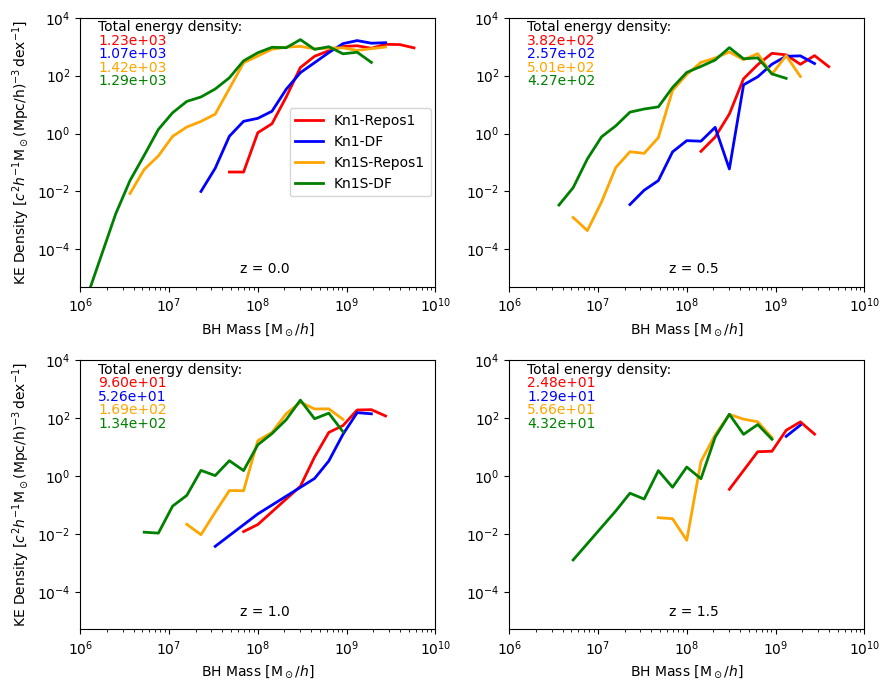

In [7]:
# 2x2 figure for redshifts

zs = np.array([0.0, 0.5, 1.0, 1.5])

m_lower = 1e6
m_upper = 1e10
colors = ['red', 'blue', 'orange', 'green']

fig, axs = plt.subplots(2, 2, figsize=(9, 7))
axs = axs.flatten()

for i, z in enumerate(zs):
    if i >= 4:
        break
    ax = axs[i]
    if z in kbh_Repos1:
        u_tot_R1 = plot_energy_density_distribution(
            ax,
            kbh_Repos1[z],
            nbins=25,
            color=colors[0],
            xlower=m_lower,
            xupper=m_upper,
            label=f'Kn1-Repos1',
            linewidth=2.0
            )
    if z in kbh_DF:
        u_tot_DF = plot_energy_density_distribution(
            ax,
            kbh_DF[z],
            nbins=25,
            color=colors[1],
            xlower=m_lower,
            xupper=m_upper,
            label=f'Kn1-DF',
            linewidth=2.0
            )
    if z in kbh_SRepos1:
        u_tot_SR1 = plot_energy_density_distribution(
            ax,
            kbh_SRepos1[z],
            nbins=25,
            color=colors[2],
            xlower=m_lower,
            xupper=m_upper,
            label=f'Kn1S-Repos1',
            linewidth=2.0
            )
    if z in kbh_SDF:
        u_tot_SDF = plot_energy_density_distribution(
            ax,
            kbh_SDF[z],
            nbins=25,
            color=colors[3],
            xlower=m_lower,
            xupper=m_upper,
            label=f'Kn1S-DF',
            linewidth=2.0
            )
    # annotate total energy density for each model with different colors
    ax.text(0.05, .95, 'Total energy density:', transform=ax.transAxes)  # placeholder for alignment
    if z in kbh_Repos1:
        ax.text(0.05, 0.9, f'{u_tot_R1:.2e}', transform=ax.transAxes, color=colors[0])
    if z in kbh_DF:
        ax.text(0.05, 0.85, f'{u_tot_DF:.2e}', transform=ax.transAxes, color=colors[1])
    if z in kbh_SRepos1:
        ax.text(0.05, 0.8, f'{u_tot_SR1:.2e}', transform=ax.transAxes, color=colors[2])
    if z in kbh_SDF:
        ax.text(0.05, 0.75, f'{u_tot_SDF:.2e}', transform=ax.transAxes, color=colors[3])

    # ax.set_title(f'z = {z:.1f}')
    # annotate z using text instead of title
    ax.text(0.45, 0.05, f'z = {z:.1f}', transform=ax.transAxes)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'BH Mass [M$_\odot/h$]')
    if i % 2 == 0:
        ax.set_ylabel(r'KE Density [$c^2h^{-1}$M$_\odot$(Mpc/h)$^{-3}\,\mathrm{dex}^{-1}$]')
    # ax.legend()
    # x limit
    ax.set_xlim(m_lower, m_upper)
    ax.set_ylim(.5e-5, 1e4)
# legend only for the first subplot
axs[0].legend(loc='center left', bbox_to_anchor=(.57, 0.5))
plt.tight_layout()
plt.show()

Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 1.071e+03 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 1.233e+03 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 1.289e+03 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 1.418e+03 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 2.570e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 3.819e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 4.274e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 5.011e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 5.258e+01 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 9.602e+01 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+06 to 1.0e+10 Msun/h): 1.337e+02 c^2 Msun/h / (Mpc/h)^3
Total energy density (from 1.0e+

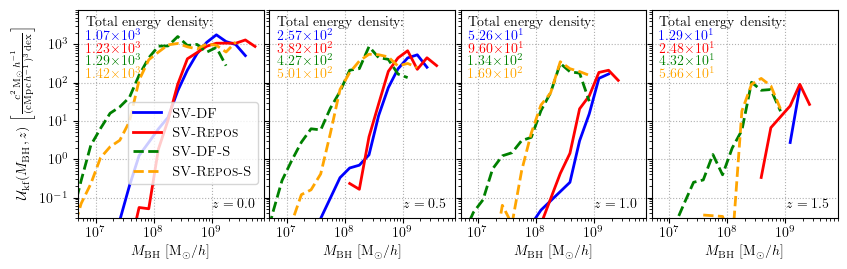

In [13]:
# 1x4 figure for redshifts

import matplotlib as mpl
mpl.rcParams['text.usetex'] = True
# font
plt.rcParams["font.family"] = 'Nimbus Roman'
plt.rcParams['mathtext.fontset'] = 'cm'

zs = np.array([0.0, 0.5, 1.0, 1.5])

m_lower = 1e6
m_upper = 1e10
bins = 24
colors = ['blue', 'red', 'green', 'orange']
lstyles = ['-', '-', '--', '--']
sim_names = [r'$\textsc{SV-DF}$', r'$\textsc{SV-Repos}$', r'$\textsc{SV-DF-S}$', r'$\textsc{SV-Repos-S}$']

def sci_notation(x, digits=2):
    return f'{x:.{digits}e}'[:-4] + r"$\times 10^{" + str(int(f'{x:.{digits}e}'.split('e')[1])) + r"}$"

fig, axs = plt.subplots(1, 4, figsize=(9.8, 2.7))
fig.subplots_adjust(wspace=0.03)
axs = axs.flatten()

for i, z in enumerate(zs):
    ax = axs[i]
    if z in kbh_DF:
        u_tot_DF = plot_energy_density_distribution(
            ax,
            kbh_DF[z],
            nbins=bins,
            color=colors[0],
            xlower=m_lower,
            xupper=m_upper,
            label=sim_names[0],
            ls=lstyles[0]
            )
    if z in kbh_Repos1:
        u_tot_R1 = plot_energy_density_distribution(
            ax,
            kbh_Repos1[z],
            nbins=bins,
            color=colors[1],
            xlower=m_lower,
            xupper=m_upper,
            label=sim_names[1],
            ls=lstyles[1]
            )
    if z in kbh_SDF:
        u_tot_SDF = plot_energy_density_distribution(
            ax,
            kbh_SDF[z],
            nbins=bins,
            color=colors[2],
            xlower=m_lower,
            xupper=m_upper,
            label=sim_names[2],
            ls=lstyles[2]
            )
    if z in kbh_SRepos1:
        u_tot_SR1 = plot_energy_density_distribution(
            ax,
            kbh_SRepos1[z],
            nbins=bins,
            color=colors[3],
            xlower=m_lower,
            xupper=m_upper,
            label=sim_names[3],
            ls=lstyles[3]
            )
        
    # annotate total energy density for each model with different colors
    ax.text(0.04, .92, 'Total energy density:', transform=ax.transAxes)  # placeholder for alignment
    if z in kbh_DF:
        ax.text(0.04, 0.86, sci_notation(u_tot_DF), transform=ax.transAxes, color=colors[0])
    if z in kbh_Repos1:
        ax.text(0.04, 0.80, sci_notation(u_tot_R1), transform=ax.transAxes, color=colors[1])
    if z in kbh_SDF:
        ax.text(0.04, 0.74, sci_notation(u_tot_SDF), transform=ax.transAxes, color=colors[2])
    if z in kbh_SRepos1:
        ax.text(0.04, 0.68, sci_notation(u_tot_SR1), transform=ax.transAxes, color=colors[3])
    

    # ax.set_title(f'z = {z:.1f}')
    # annotate z using text instead of title
    ax.text(0.72, 0.05, r'$z = %.1f$' % z, transform=ax.transAxes)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$M_\mathrm{BH}$ [M$_\odot/h$]')
    if i == 0:
        # ax.set_ylabel(r'KE Density [$c^2h^{-1}$M$_\odot$(Mpc/h)$^{-3}\,\mathrm{dex}^{-1}$]')
        ax.set_ylabel(r'$\mathcal{U}_\mathrm{kf}(M_\mathrm{BH},z)$ $\left[\frac{c^2\,\mathrm{M}_\odot\,h^{-1}}{ (\mathrm{cMpc}\,h^{-1})^{3}\,\mathrm{dex} }\right]$')
    else:
        ax.set_yticklabels([])
    # x limit
    ax.set_xlim(5e6, .8e10)
    ax.set_ylim(3e-2, .8e4)
    ax.grid(ls=":")
# legend only for the first subplot
axs[0].legend(loc='lower left', bbox_to_anchor=(.23, 0.13))
# plt.tight_layout()
# plt.show()
plt.savefig('fig_KE_density_MBH.pdf',  bbox_inches='tight')

In [9]:
# # plot energy distribution

# fig, ax = plt.subplots(figsize=(5, 4))

# m_lower = 1e6
# m_upper = 1e10

# # for i, z in enumerate(zs):
# #     if z not in kbh_DF:
# #         continue
# #     plot_energy_density_distribution(
# #         ax,
# #         kbh_DF[z],
# #         nbins=25,
# #         color='blue',
# #         xlower=m_lower,
# #         xupper=m_upper,
# #         label=f'Kn1-DF' if i == 0 else None,
# #         linewidth=line_widths[i]
# #         )


# # for i, z in enumerate(zs):
# #     if z not in kbh_Repos1:
# #         continue
# #     plot_energy_density_distribution(
# #         ax,
# #         kbh_Repos1[z],
# #         nbins=25,
# #         color='red',
# #         xlower=m_lower,
# #         xupper=m_upper,
# #         label=f'Kn1-Repos1' if i == 0 else None,
# #         linewidth=line_widths[i]
# #         )

# for i, z in enumerate(zs):
#     if z not in kbh_SRepos1:
#         continue
#     plot_energy_density_distribution(
#         ax,
#         kbh_SRepos1_prim[z],
#         nbins=25,
#         color='orange',
#         xlower=m_lower,
#         xupper=m_upper,
#         label=f'Kn1S-Repos1' if i == 0 else None,
#         linewidth=line_widths[i]
#         )


# for i, z in enumerate(zs):
#     if z not in kbh_SDF:
#         continue
#     plot_energy_density_distribution(
#         ax,
#         kbh_SDF_prim[z],
#         nbins=25,
#         color='green',
#         xlower=m_lower,
#         xupper=m_upper,
#         label=f'Kn1S-DF' if i == 0 else None,
#         linewidth=line_widths[i]
#         )


# # scale
# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.set_xlabel(r'BH Mass [M$_\odot/h$]')
# # ax.set_ylabel(r'Energy Density [$c^2$M$_\odot/h$/Mpc$^3$]')
# ax.legend()
# plt.tight_layout()
# plt.show()